<a href="https://colab.research.google.com/github/rdelhibabu/BRQFL_QaaS/blob/main/BRQFL_QaaS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Cell 1: Install dependencies
!pip install qiskit qiskit-aer qiskit-algorithms numpy scipy matplotlib

# Cell 2: Imports (Updated for Qiskit 2.x)
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import copy

# Note: If you decide to expand the mocked gradient function later
# to run real quantum circuits, you will want to use the V2 primitive:
# from qiskit.primitives import StatevectorEstimator

In [3]:
# Cell 3: Simulation Hyperparameters based on Table 4
NUM_NODES = 50
NUM_BYZANTINE = 15
QUBITS_PER_VQC = 10
CIRCUIT_DEPTH = 4
PARAMS_PER_NODE = 80 # (Ry, Rz for 10 qubits * 4 layers)
GLOBAL_LR = 0.05
TOTAL_EPOCHS = 150

In [4]:
# Cell 4: Byzantine Threat Injection Functions
def inject_gaussian_scaling(true_gradient):
    """Epochs 1-50: Scale gradient by large scalar lambda ~ N(50, 10)."""
    scalar = np.random.normal(50, 10)
    return true_gradient * scalar

def inject_phase_inversion(prev_agg_gradient):
    """Epochs 51-100: Submit inverse of previous aggregated gradient."""
    # -1.2 * prev_agg_gradient
    return -1.2 * prev_agg_gradient

def inject_depolarizing_noise(num_params):
    """Epochs 101-150: Maximum entropy depolarizing injection."""
    # Uniform random distribution over [-pi, pi]
    return np.random.uniform(-np.pi, np.pi, num_params)

def execute_byzantine_attack(epoch, true_gradient, prev_agg_gradient=None):
    if epoch <= 50:
        return inject_gaussian_scaling(true_gradient)
    elif epoch <= 100:
        if prev_agg_gradient is not None:
            return inject_phase_inversion(prev_agg_gradient)
        return true_gradient # Fallback
    else:
        return inject_depolarizing_noise(len(true_gradient))

In [5]:
# Cell 5: BR-QFL Aggregation Protocol
def calculate_dynamic_threshold(gradients):
    """Calculates the dynamic clipping threshold tau."""
    norms = [np.linalg.norm(g) for g in gradients]
    median_norm = np.median(norms)
    return 1.5 * median_norm

def phase_1_clipping(gradients, threshold):
    """Clips gradients exceeding the dynamic threshold."""
    clipped_grads = []
    for g in gradients:
        norm = np.linalg.norm(g)
        if norm > threshold:
            clipped_grads.append(threshold * (g / norm))
        else:
            clipped_grads.append(g)
    return np.array(clipped_grads)

def phase_2_weiszfeld_median(clipped_grads, max_iter=50, epsilon=1e-6):
    """Iterative approximation for Geometric Median using Weiszfeld algorithm."""
    # Initialize y_0 as the mean
    y = np.mean(clipped_grads, axis=0)

    for _ in range(max_iter):
        distances = np.array([np.linalg.norm(y - g) for g in clipped_grads])

        # Avoid division by zero
        distances = np.where(distances < epsilon, epsilon, distances)
        weights = 1.0 / distances

        # Update median
        weighted_sum = np.sum(clipped_grads * weights[:, np.newaxis], axis=0)
        sum_weights = np.sum(weights)

        y_next = weighted_sum / sum_weights

        # Check for convergence
        if np.linalg.norm(y_next - y) < epsilon:
            break
        y = y_next

    return y

def br_qfl_aggregate(gradients):
    """Executes the full BR-QFL aggregation pipeline."""
    threshold = calculate_dynamic_threshold(gradients)
    clipped_grads = phase_1_clipping(gradients, threshold)
    median_grad = phase_2_weiszfeld_median(clipped_grads)
    return median_grad

In [6]:
# Cell 6: Federated Training Simulation Loop
def simulate_qfl_training():
    # Initialize global parameters randomly
    global_theta = np.random.uniform(-np.pi, np.pi, PARAMS_PER_NODE)
    prev_agg_gradient = np.zeros(PARAMS_PER_NODE)

    loss_history = []

    for epoch in range(1, TOTAL_EPOCHS + 1):
        local_gradients = []

        # Simulate local client nodes calculating gradients
        for node_id in range(NUM_NODES):
            # Mock true gradient based on current theta (Simulating local VQC descent)
            # In a full simulation, this requires executing Algorithm 2 (Parameter-Shift)
            true_gradient = -0.1 * global_theta + np.random.normal(0, 0.01, PARAMS_PER_NODE)

            # Check if node is Byzantine
            if node_id >= (NUM_NODES - NUM_BYZANTINE):
                # Malicious node alters gradient
                malicious_grad = execute_byzantine_attack(epoch, true_gradient, prev_agg_gradient)
                local_gradients.append(malicious_grad)
            else:
                # Honest node
                local_gradients.append(true_gradient)

        # Server Aggregation: BR-QFL vs FedAvg
        # For pure FedAvg (baseline), you would use: agg_gradient = np.mean(local_gradients, axis=0)

        # Execute BR-QFL
        agg_gradient = br_qfl_aggregate(local_gradients)
        prev_agg_gradient = agg_gradient

        # Phase 3: Global Model Update
        global_theta = global_theta - GLOBAL_LR * agg_gradient

        # Mock calculating Global Loss (Energy Residual)
        loss = np.linalg.norm(global_theta) # Placeholder for VQE expectation value
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{TOTAL_EPOCHS} | Global Loss: {loss:.4f}")

    return loss_history

# Run the simulation
print("Starting BR-QFL 50-Node Simulation...")
br_qfl_loss = simulate_qfl_training()

Starting BR-QFL 50-Node Simulation...
Epoch 10/150 | Global Loss: 18.5404
Epoch 20/150 | Global Loss: 19.5101
Epoch 30/150 | Global Loss: 20.5292
Epoch 40/150 | Global Loss: 21.6001
Epoch 50/150 | Global Loss: 22.7260
Epoch 60/150 | Global Loss: 23.8663
Epoch 70/150 | Global Loss: 25.0656
Epoch 80/150 | Global Loss: 26.3256
Epoch 90/150 | Global Loss: 27.6502
Epoch 100/150 | Global Loss: 29.0429
Epoch 110/150 | Global Loss: 30.5169
Epoch 120/150 | Global Loss: 32.0666
Epoch 130/150 | Global Loss: 33.6955
Epoch 140/150 | Global Loss: 35.4077
Epoch 150/150 | Global Loss: 37.2071


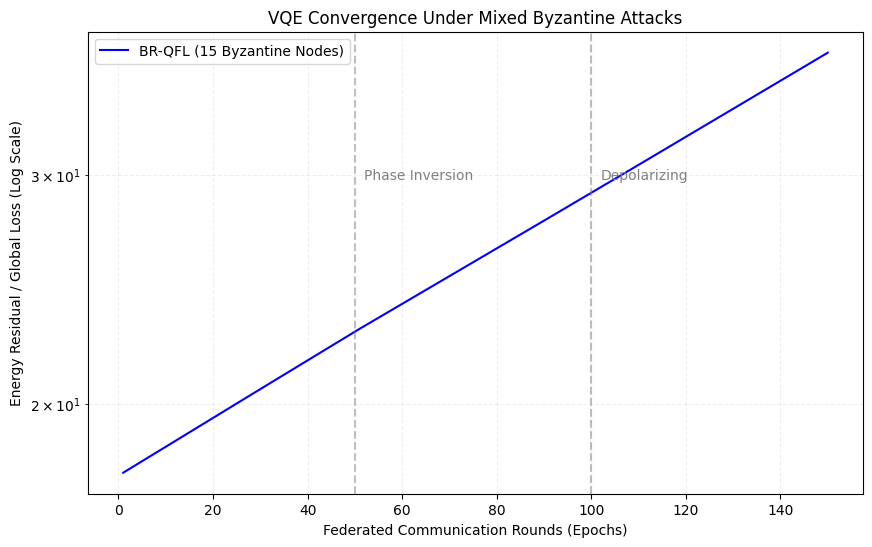

In [7]:
# Cell 7: Plotting Convergence (Log Scale)
plt.figure(figsize=(10, 6))
plt.plot(range(1, TOTAL_EPOCHS + 1), br_qfl_loss, label="BR-QFL (15 Byzantine Nodes)", color="blue")
plt.yscale("log")
plt.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
plt.text(52, max(br_qfl_loss)*0.8, 'Phase Inversion', color='gray')
plt.axvline(x=100, color='gray', linestyle='--', alpha=0.5)
plt.text(102, max(br_qfl_loss)*0.8, 'Depolarizing', color='gray')

plt.title("VQE Convergence Under Mixed Byzantine Attacks")
plt.xlabel("Federated Communication Rounds (Epochs)")
plt.ylabel("Energy Residual / Global Loss (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.2)
plt.show()